# Capital Bikeshare Demand Analysis & Forecasting

This notebook uses hourly Capital Bikeshare rentals from Washington, D.C. to study demand patterns, fit a regression model, and forecast total hourly rentals.

**Workflow**
1. Data Collection
2. Data Wrangling
3. Exploratory Data Analysis
4. Statistical & Regression Analysis
5. Feature Engineering
6. Demand Forecasting
7. Conclusions



### Imports

Load libraries used across the noteboook.


In [150]:
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler


## 1. Data Collection

Pull the UCI Bike Sharing dataset if it is not already on disk, then load the hourly dataset.



### 1.1 Data source

| Item | Detail |
|------|--------|
| Source | UCI Machine Learning Repository — Bike Sharing Dataset |
| Dataset page | https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset |
| Download URL | https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip |
| System | Capital Bikeshare, Washington, D.C. |
| Period | ~2 years |
| Primary file | `hour.csv` (hourly) |
| Optional file | `day.csv` (daily) |
| Local path | `data/raw/` |



### 1.2 Dataset files

- `hour.csv` — hourly rentals with calendar and weather fields (main analysis table)
- `day.csv` — daily totals (optional reference only)
- `Readme.txt` — field documentation from the source

All forecasting work uses the hourly file.



### 1.3 Data dictionary

| Field | Description |
|-------|-------------|
| `instant` | Record index |
| `dteday` | Date |
| `season` | 1 = spring, 2 = summer, 3 = fall, 4 = winter |
| `yr` | Year (0 = 2011, 1 = 2012) |
| `mnth` | Month (1–12) |
| `hr` | Hour (0–23) |
| `holiday` | 1 = holiday, 0 = otherwise |
| `weekday` | Day of week (0–6) |
| `workingday` | 1 = working day, 0 = weekend/holiday |
| `weathersit` | 1 = clear, 2 = mist/cloud, 3 = light rain/snow, 4 = heavy rain/snow |
| `temp` | Normalized temperature |
| `atemp` | Normalized feels-like temperature |
| `hum` | Normalized humidity |
| `windspeed` | Normalized wind speed |
| `casual` | Casual (non-registered) rentals |
| `registered` | Registered rentals |
| `cnt` | Total rentals |

Column names and types are cleaned in Data Wrangling.



### 1.4 Download and load data

Download the zip when needed, then read `hour.csv` (and optionally `day.csv`) into pandas.



In [151]:
DATA_RAW = Path("data/raw")
HOUR_CSV = DATA_RAW / "hour.csv"
DAY_CSV = DATA_RAW / "day.csv"
ZIP_PATH = DATA_RAW / "bike+sharing+dataset.zip"
DATA_URL = "https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip"

DATA_RAW.mkdir(parents=True, exist_ok=True)

if not HOUR_CSV.exists():
    print("Downloading Bike Sharing dataset from UCI...")
    urlretrieve(DATA_URL, ZIP_PATH)
    with ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATA_RAW)
    print(f"Downloaded and extracted to {DATA_RAW.resolve()}")
else:
    print(f"Using existing data in {DATA_RAW.resolve()}")


Using existing data in C:\Users\Ibuchi Basil\data-science\bike-share\bike-share-main\data\raw


In [152]:
# Load hourly dataset
df_raw = pd.read_csv(HOUR_CSV)

print("Shape (rows, columns):", df_raw.shape)
print("\nColumn names:")
print(list(df_raw.columns))
df_raw.head()

Shape (rows, columns): (17379, 17)

Column names:
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [153]:
# dtype overview
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [154]:
# Date coverage and basic demand summary from raw columns
# UCI hour.csv uses: dteday, hr, casual, registered, cnt

print("Date range:", df_raw["dteday"].min(), "→", df_raw["dteday"].max())
print("Missing values (total):", int(df_raw.isnull().sum().sum()))
print("\nDemand columns — descriptive snapshot:")
df_raw[["casual", "registered", "cnt"]].describe()

Date range: 2011-01-01 → 2012-12-31
Missing values (total): 0

Demand columns — descriptive snapshot:


,casual,registered,cnt
count,17379.000000,17379.000000,17379.000000
mean,35.676218,153.786869,189.463088
std,49.305030,151.357286,181.387599
min,0.000000,0.000000,1.000000
25%,4.000000,34.000000,40.000000
50%,17.000000,115.000000,142.000000
75%,48.000000,220.000000,281.000000
max,367.000000,886.000000,977.000000


In [155]:
# Daily shape
df_day_raw = pd.read_csv(DAY_CSV)
print("Daily shape (rows, columns):", df_day_raw.shape)
df_day_raw.head(3)

Daily shape (rows, columns): (731, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349


In [156]:
# Keep an untouched raw hourly copy for later stages
RAW_CHECKPOINT = DATA_RAW / "raw_hour_checkpoint.csv"
df_raw.to_csv(RAW_CHECKPOINT, index=False)
print(f"Saved raw hourly checkpoint → {RAW_CHECKPOINT.resolve()}")

Saved raw hourly checkpoint → C:\Users\Ibuchi Basil\data-science\bike-share\bike-share-main\data\raw\raw_hour_checkpoint.csv


### 1.5 Collection summary

- Downloaded from UCI only if `hour.csv` was missing
- Main table: `hour.csv` → `df_raw`
- Optional: `day.csv` → `df_day_raw`
- Saved a raw hourly checkpoint for the next steps



## 2. Data Wrangling

Turn the raw hourly dataset into a clean analysis table: fix time, rename fields, validate demand, and save a processed file.

### 2.1 Inspect raw data

Check shape, types, missing values, and a quick preview before changing anything.


In [157]:
RAW_CHECKPOINT = Path("data/raw/raw_hour_checkpoint.csv")
df = pd.read_csv(RAW_CHECKPOINT)
df.shape

(17379, 17)

In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [159]:
print("Missing values:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Duplicate rows: 0


### 2.2 Create datetime index

Combine date and hour into one `datetime` column and sort the rows in time order.



In [160]:
# Combine date + hour into a single hourly timestamp, then sort chronologically
df["datetime"] = pd.to_datetime(df["dteday"]) + pd.to_timedelta(df["hr"], unit="h")
df = df.sort_values("datetime").reset_index(drop=True)

print(df["datetime"].min(), "→", df["datetime"].max())
print("Duplicate timestamps:", df["datetime"].duplicated().sum())
df[["dteday", "hr", "datetime"]].head()

2011-01-01 00:00:00 → 2012-12-31 23:00:00
Duplicate timestamps: 0


,dteday,hr,datetime
0,2011-01-01,0,2011-01-01 00:00:00
1,2011-01-01,1,2011-01-01 01:00:00
2,2011-01-01,2,2011-01-01 02:00:00
3,2011-01-01,3,2011-01-01 03:00:00
4,2011-01-01,4,2011-01-01 04:00:00


### 2.3 Rename and standardize columns

Rename short source names to clearer labels (`hr` → `hour`, `cnt` → `count`, and so on) so later sections stay readable.



In [161]:
# Make column names more explicit
df = df.rename(columns={
    "hr": "hour",
    "yr": "year",
    "cnt": "count",
    "mnth": "month",
    "hum": "humidity",
    "dteday": "dateday",
    "weathersit": "weather",
})
df.columns.tolist()

['instant',
 'dateday',
 'season',
 'year',
 'month',
 'hour',
 'holiday',
 'weekday',
 'workingday',
 'weather',
 'temp',
 'atemp',
 'humidity',
 'windspeed',
 'casual',
 'registered',
 'count',
 'datetime']

### 2.4 Validate demand and coded fields

Confirm `count = casual + registered`, and check that coded fields stay inside their expected ranges.



In [162]:
# Demand identity: count should equal casual + registered
mismatch = (df["count"] != df["casual"] + df["registered"]).sum()
print("count != casual + registered:", mismatch)

# Expected value ranges for coded fields
print("\nValue ranges:")
print("season:", sorted(df["season"].unique().tolist()))
print("year:", sorted(df["year"].unique().tolist()))
print("month:", sorted(df["month"].unique().tolist()))
print("hour:", sorted(df["hour"].unique().tolist()))
print("holiday:", sorted(df["holiday"].unique().tolist()))
print("weekday:", sorted(df["weekday"].unique().tolist()))
print("workingday:", sorted(df["workingday"].unique().tolist()))
print("weather:", sorted(df["weather"].unique().tolist()))


count != casual + registered: 0

Value ranges:
season: [1, 2, 3, 4]
year: [0, 1]
month: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
hour: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
holiday: [0, 1]
weekday: [0, 1, 2, 3, 4, 5, 6]
workingday: [0, 1]
weather: [1, 2, 3, 4]


### 2.5 Data quality checks

Review normalized weather scales, zeros, duplicates, and anything else that looks off before modeling.



In [163]:
# Weather features are normalized in the UCI file (approx. 0–1)
weather_cols = ["temp", "atemp", "humidity", "windspeed"]
print(df[weather_cols].describe().round(3))

print("\nhumidity == 0:", (df["humidity"] == 0).sum())
print("windspeed == 0:", (df["windspeed"] == 0).sum())
print("count == 0:", (df["count"] == 0).sum())


            temp      atemp   humidity  windspeed
count  17379.000  17379.000  17379.000  17379.000
mean       0.497      0.476      0.627      0.190
std        0.193      0.172      0.193      0.122
min        0.020      0.000      0.000      0.000
25%        0.340      0.333      0.480      0.104
50%        0.500      0.485      0.630      0.194
75%        0.660      0.621      0.780      0.254
max        1.000      1.000      1.000      0.851

humidity == 0: 22
windspeed == 0: 2180
count == 0: 0


### 2.6 Add calendar helpers

Add `dayofmonth` from `datetime`. It is only used later for the days 1–20 / 21–end split, not as a model feature.



In [164]:
# Day of month is needed later for the days 1–20 / 21–end split
df["dayofmonth"] = df["datetime"].dt.day
df[["datetime", "year", "month", "dayofmonth", "hour"]].head()


,datetime,year,month,dayofmonth,hour
0,2011-01-01 00:00:00,0,1,1,0
1,2011-01-01 01:00:00,0,1,1,1
2,2011-01-01 02:00:00,0,1,1,2
3,2011-01-01 03:00:00,0,1,1,3
4,2011-01-01 04:00:00,0,1,1,4


### 2.7 Drop unused columns and save cleaned data

Drop columns that are no longer needed, then write the cleaned hourly table to `data/processed/`.



In [165]:
df = df.drop(columns=["instant", "dateday"])

DATA_PROCESSED = Path("data/processed")
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
CLEAN_CHECKPOINT = DATA_PROCESSED / "bike_hourly_clean.csv"
df.to_csv(CLEAN_CHECKPOINT, index=False)

print("Saved:", CLEAN_CHECKPOINT.resolve())
print("Shape:", df.shape)
df.head()

Saved: C:\Users\Ibuchi Basil\data-science\bike-share\bike-share-main\data\processed\bike_hourly_clean.csv
Shape: (17379, 17)


,season,year,month,hour,holiday,weekday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,datetime,dayofmonth
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,2011-01-01 00:00:00,1
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,2011-01-01 01:00:00,1
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,2011-01-01 02:00:00,1
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,2011-01-01 03:00:00,1
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,2011-01-01 04:00:00,1


### 2.8 Wrangling summary

- Reloaded hourly data from the raw checkpoint
- Built a sorted `datetime` from date + hour
- Renamed columns for clarity (`hour`, `year`, `month`, `weather`, `humidity`, `count`, etc.)
- Checked that `count = casual + registered` and that coded fields stay in range
- Reviewed normalized weather scales and zero counts
- Added `dayofmonth` for the later train/test split
- Dropped `instant` and `dateday`
- Saved the cleaned table to `data/processed/bike_hourly_clean.csv`



## 3. Exploratory Data Analysis

This section covers how hourly demand varies before any models are fit — overall shape, time patterns, weather, and casual vs registered use.

### 3.1 Demand overview

Distribution of total, casual, and registered rentals: scale, skew, and how often hours are quiet vs busy.


In [166]:
df = pd.read_csv(
    Path("data/processed/bike_hourly_clean.csv"),
    parse_dates=["datetime"],
)
df[["casual", "registered", "count"]].describe().round(2)


,casual,registered,count
count,17379.00,17379.00,17379.00
mean,35.68,153.79,189.46
std,49.31,151.36,181.39
min,0.00,0.00,1.00
25%,4.00,34.00,40.00
50%,17.00,115.00,142.00
75%,48.00,220.00,281.00
max,367.00,886.00,977.00


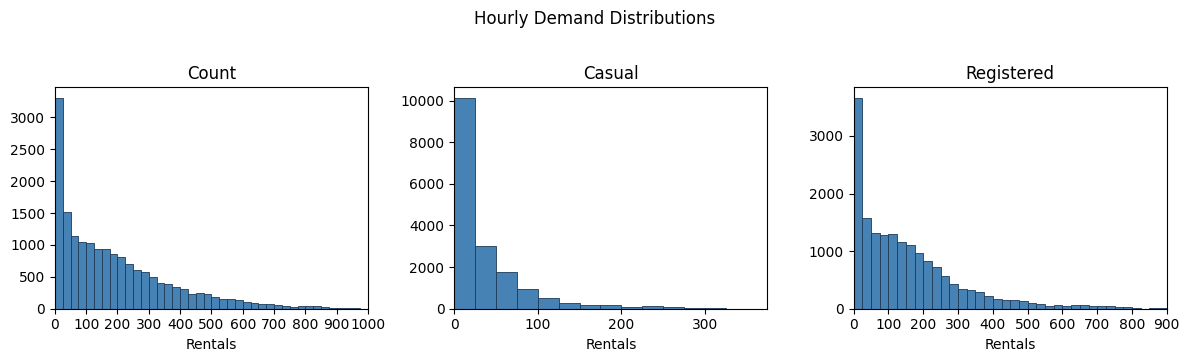

Zero-rental hours — count: 0 | casual: 1581 | registered: 24


In [167]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
bin_width = 25
for ax, col in zip(axes, ["count", "casual", "registered"]):
    bins = np.arange(0, df[col].max() + bin_width, bin_width)
    ax.hist(df[col], bins=bins, color="steelblue", edgecolor="#1f3a56", linewidth=0.6)
    ax.set_title(col.title())
    ax.set_xlabel("Rentals")
    ax.set_xticks(bins[::4])  # every 100 rentals
    ax.set_xlim(0, bins[-1])
    ax.set_ylim(bottom=0)
fig.suptitle("Hourly Demand Distributions", y=1.02)
plt.tight_layout()
plt.show()

print("Zero-rental hours — count:", (df["count"] == 0).sum(),
      "| casual:", (df["casual"] == 0).sum(),
      "| registered:", (df["registered"] == 0).sum())


### 3.2 Temporal patterns

Mean demand by hour, weekday, month, season, and working day vs weekend/holiday.



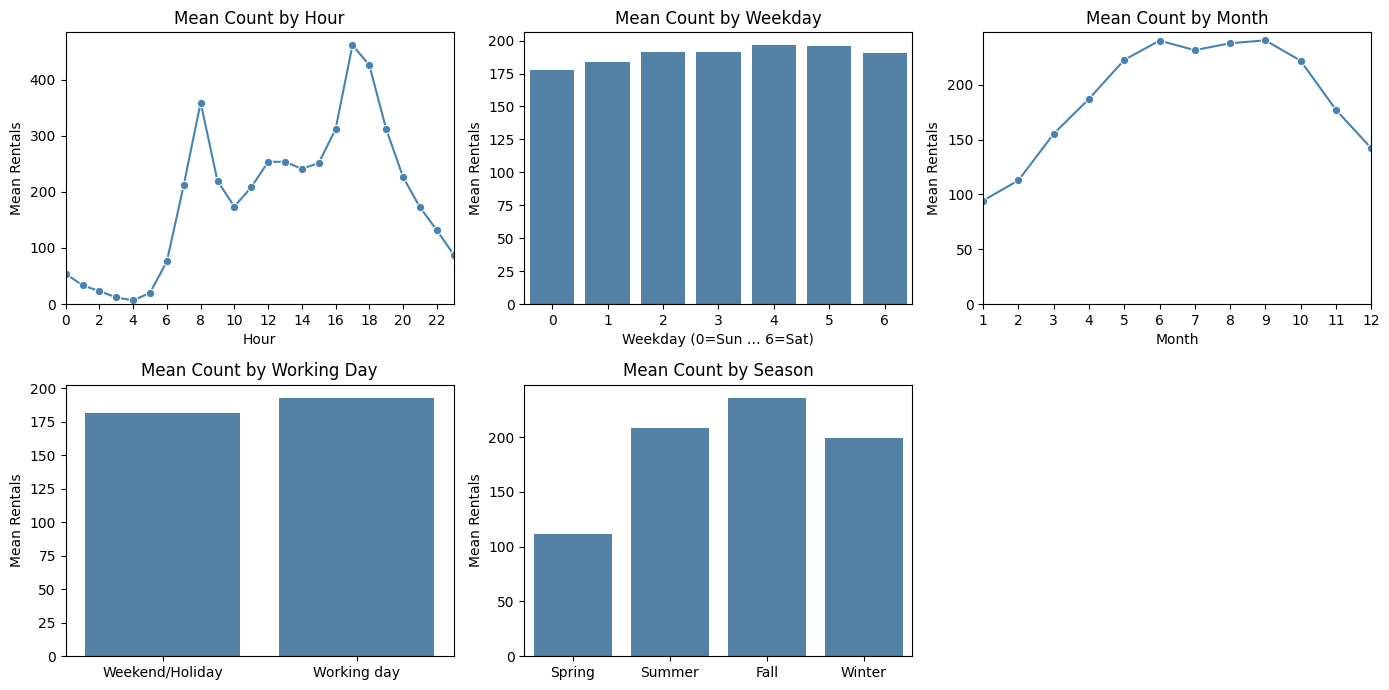

In [168]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

# Hour of day
by_hour = df.groupby("hour", as_index=False)["count"].mean()
sns.lineplot(data=by_hour, x="hour", y="count", marker="o", color="steelblue", ax=axes[0, 0])
axes[0, 0].set_title("Mean Count by Hour")
axes[0, 0].set_xlabel("Hour")
axes[0, 0].set_ylabel("Mean Rentals")
axes[0, 0].set_xticks(range(0, 24, 2))
axes[0, 0].set_xlim(0, 23)
axes[0, 0].set_ylim(bottom=0)

# Day of week
by_weekday = df.groupby("weekday", as_index=False)["count"].mean()
sns.barplot(data=by_weekday, x="weekday", y="count", color="steelblue", ax=axes[0, 1])
axes[0, 1].set_title("Mean Count by Weekday")
axes[0, 1].set_xlabel("Weekday (0=Sun … 6=Sat)")
axes[0, 1].set_ylabel("Mean Rentals")
axes[0, 1].set_ylim(bottom=0)

# Month
by_month = df.groupby("month", as_index=False)["count"].mean()
sns.lineplot(data=by_month, x="month", y="count", marker="o", color="steelblue", ax=axes[0, 2])
axes[0, 2].set_title("Mean Count by Month")
axes[0, 2].set_xlabel("Month")
axes[0, 2].set_ylabel("Mean Rentals")
axes[0, 2].set_xticks(range(1, 13))
axes[0, 2].set_xlim(1, 12)
axes[0, 2].set_ylim(bottom=0)

# Working day vs weekend/holiday
by_workingday = df.groupby("workingday", as_index=False)["count"].mean()
by_workingday["working_label"] = by_workingday["workingday"].map({0: "Weekend/Holiday", 1: "Working day"})
sns.barplot(data=by_workingday, x="working_label", y="count", color="steelblue", ax=axes[1, 0],
            order=["Weekend/Holiday", "Working day"])
axes[1, 0].set_title("Mean Count by Working Day")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Mean Rentals")
axes[1, 0].set_ylim(bottom=0)

# Season
by_season = df.groupby("season", as_index=False)["count"].mean()
by_season["season_label"] = by_season["season"].map({1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"})
sns.barplot(data=by_season, x="season_label", y="count", color="steelblue", ax=axes[1, 1],
            order=["Spring", "Summer", "Fall", "Winter"])
axes[1, 1].set_title("Mean Count by Season")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Mean Rentals")
axes[1, 1].set_ylim(bottom=0)

axes[1, 2].axis("off")
plt.tight_layout()
plt.show()


### 3.3 Weather effects

How mean demand changes with weather category, temperature, humidity, and windspeed.



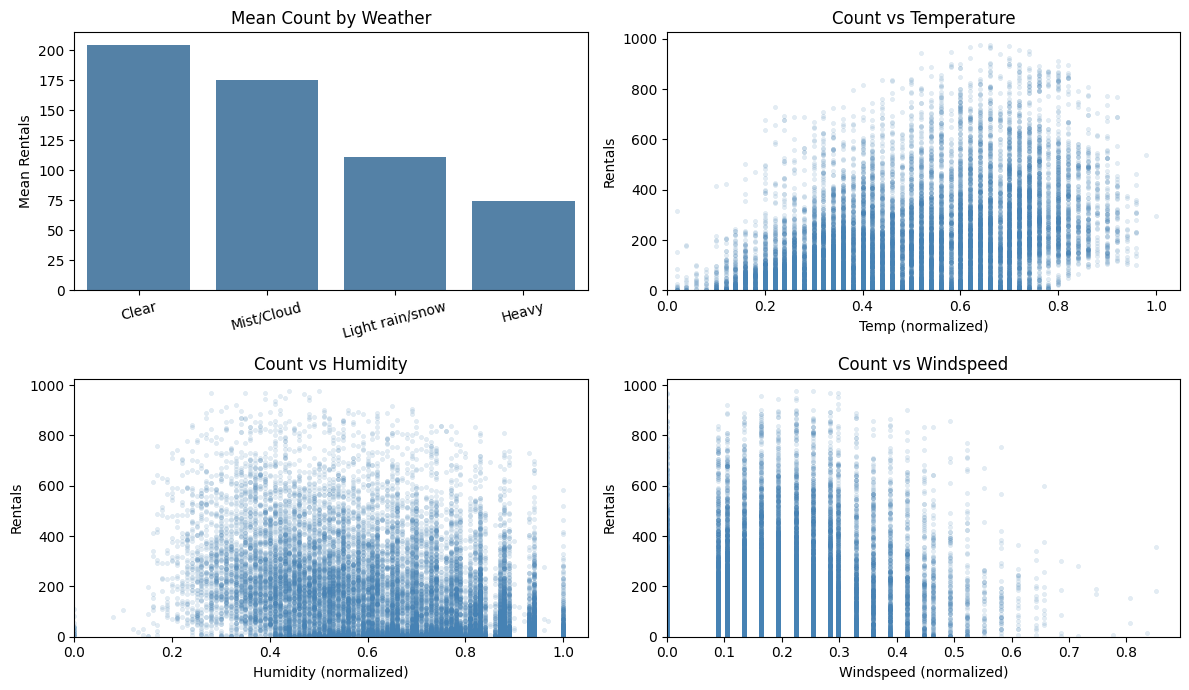

In [169]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# Weather category
by_weather = df.groupby("weather", as_index=False)["count"].mean()
by_weather["weather_label"] = by_weather["weather"].map(
    {1: "Clear", 2: "Mist/Cloud", 3: "Light rain/snow", 4: "Heavy"}
)
sns.barplot(data=by_weather, x="weather_label", y="count", color="steelblue", ax=axes[0, 0],
            order=["Clear", "Mist/Cloud", "Light rain/snow", "Heavy"])
axes[0, 0].set_title("Mean Count by Weather")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Mean Rentals")
axes[0, 0].tick_params(axis="x", rotation=15)
axes[0, 0].set_ylim(bottom=0)

# Temperature (normalized)
sns.scatterplot(data=df, x="temp", y="count", alpha=0.15, s=10, color="steelblue", ax=axes[0, 1], edgecolor=None)
axes[0, 1].set_title("Count vs Temperature")
axes[0, 1].set_xlabel("Temp (normalized)")
axes[0, 1].set_ylabel("Rentals")
axes[0, 1].set_xlim(left=0)
axes[0, 1].set_ylim(bottom=0)

# Humidity (normalized)
sns.scatterplot(data=df, x="humidity", y="count", alpha=0.15, s=10, color="steelblue", ax=axes[1, 0], edgecolor=None)
axes[1, 0].set_title("Count vs Humidity")
axes[1, 0].set_xlabel("Humidity (normalized)")
axes[1, 0].set_ylabel("Rentals")
axes[1, 0].set_xlim(left=0)
axes[1, 0].set_ylim(bottom=0)

# Wind speed (normalized)
sns.scatterplot(data=df, x="windspeed", y="count", alpha=0.15, s=10, color="steelblue", ax=axes[1, 1], edgecolor=None)
axes[1, 1].set_title("Count vs Windspeed")
axes[1, 1].set_xlabel("Windspeed (normalized)")
axes[1, 1].set_ylabel("Rentals")
axes[1, 1].set_xlim(left=0)
axes[1, 1].set_ylim(bottom=0)

plt.tight_layout()
plt.show()


### 3.4 Casual vs registered

Compare the two user groups on the same time and weather cuts. Registered riders tend to look more commute-driven; casual riders more leisure-driven.



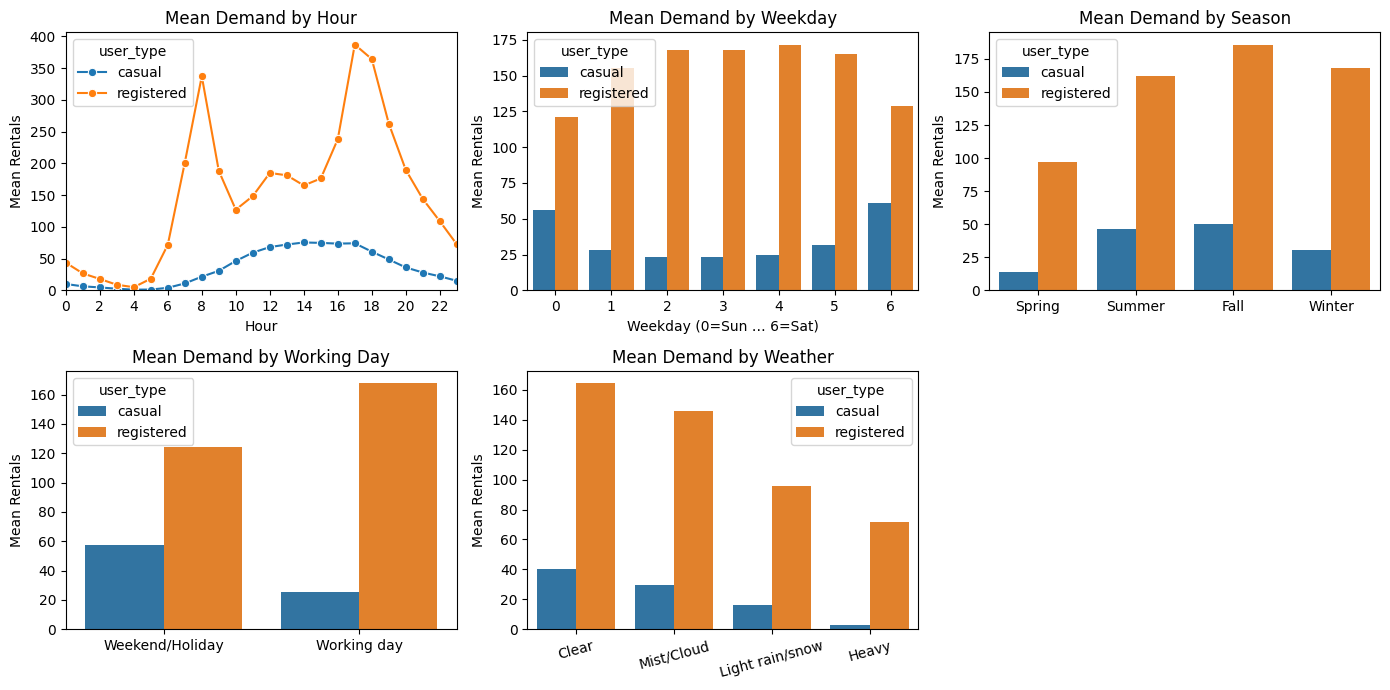

In [170]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

def mean_by(group_col):
    return (
        df.groupby(group_col, as_index=False)[["casual", "registered"]]
        .mean()
        .melt(id_vars=group_col, var_name="user_type", value_name="mean_rentals")
    )

# Hour of day
sns.lineplot(data=mean_by("hour"), x="hour", y="mean_rentals", hue="user_type", marker="o", ax=axes[0, 0])
axes[0, 0].set_title("Mean Demand by Hour")
axes[0, 0].set_xlabel("Hour")
axes[0, 0].set_ylabel("Mean Rentals")
axes[0, 0].set_xticks(range(0, 24, 2))
axes[0, 0].set_xlim(0, 23)
axes[0, 0].set_ylim(bottom=0)

# Weekday
sns.barplot(data=mean_by("weekday"), x="weekday", y="mean_rentals", hue="user_type", ax=axes[0, 1])
axes[0, 1].set_title("Mean Demand by Weekday")
axes[0, 1].set_xlabel("Weekday (0=Sun … 6=Sat)")
axes[0, 1].set_ylabel("Mean Rentals")
axes[0, 1].set_ylim(bottom=0)

# Season
season = mean_by("season")
season["season_label"] = season["season"].map({1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"})
sns.barplot(data=season, x="season_label", y="mean_rentals", hue="user_type", ax=axes[0, 2],
            order=["Spring", "Summer", "Fall", "Winter"])
axes[0, 2].set_title("Mean Demand by Season")
axes[0, 2].set_xlabel("")
axes[0, 2].set_ylabel("Mean Rentals")
axes[0, 2].set_ylim(bottom=0)

# Working day
working = mean_by("workingday")
working["working_label"] = working["workingday"].map({0: "Weekend/Holiday", 1: "Working day"})
sns.barplot(data=working, x="working_label", y="mean_rentals", hue="user_type", ax=axes[1, 0],
            order=["Weekend/Holiday", "Working day"])
axes[1, 0].set_title("Mean Demand by Working Day")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Mean Rentals")
axes[1, 0].set_ylim(bottom=0)

# Weather
weather = mean_by("weather")
weather["weather_label"] = weather["weather"].map(
    {1: "Clear", 2: "Mist/Cloud", 3: "Light rain/snow", 4: "Heavy"}
)
sns.barplot(data=weather, x="weather_label", y="mean_rentals", hue="user_type", ax=axes[1, 1],
            order=["Clear", "Mist/Cloud", "Light rain/snow", "Heavy"])
axes[1, 1].set_title("Mean Demand by Weather")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Mean Rentals")
axes[1, 1].tick_params(axis="x", rotation=15)
axes[1, 1].set_ylim(bottom=0)

axes[1, 2].axis("off")
plt.tight_layout()
plt.show()


### 3.5 EDA findings

- Demand is right-skewed: mean hourly `count` is about 190, with many quiet hours and a long upper tail (max 977). Registered users make up most of the volume on average (~154 vs ~36 casual).
- **Time:** Rentals peak in late afternoon (about 17:00–18:00) and again near the morning commute (~08:00). Overnight demand is very low. Fall and summer are strongest; spring is weakest. Working days are only slightly higher than weekends/holidays overall.
- **Weather:** Clear hours have the highest mean demand; rentals fall as weather worsens. Warmer temperatures go with higher demand; higher humidity goes with lower demand. Windspeed has only a weak link. Heavy weather is rare in this dataset.
- **Casual vs registered:** Registered demand shows clear commute peaks. Casual demand peaks mid-afternoon and is higher on weekends/holidays. Registered demand is higher on working days. Both groups drop in worse weather, but registered volume stays larger.



## 4. Statistical & Regression Analysis

Use Ordinary Least Squares (OLS) to relate hourly `count` to calendar and weather predictors, and to check multicollinearity and non-linearity before forecasting.

### 4.1 Target and predictors

- **Dependent variable (`y`):** `count` — total hourly rentals (`registered` + `casual`).
- **Independent variables (`X`):** `season`, `year`, `month`, `hour`, `holiday`, `weekday`, `workingday`, `weather`, `temp`, `atemp`, `humidity`, `windspeed`.


In [171]:
df = pd.read_csv(
    Path("data/processed/bike_hourly_clean.csv"),
    parse_dates=["datetime"],
)

target = "count"
predictors = [
    "season",
    "year",
    "month",
    "hour",
    "holiday",
    "weekday",
    "workingday",
    "weather",
    "temp",
    "atemp",
    "humidity",
    "windspeed",
]

y = df[target]
X = df[predictors]

print("Target:", target)
print("Predictors:", predictors)
print("X shape:", X.shape)
X.head()

Target: count
Predictors: ['season', 'year', 'month', 'hour', 'holiday', 'weekday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed']
X shape: (17379, 12)


,season,year,month,hour,holiday,weekday,workingday,weather,temp,atemp,humidity,windspeed
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0


### 4.2 Statistical considerations

Before fitting OLS, check three things that affect how we specify the model: the shape of `count`, collinearity among weather variables, and whether effects look linear.



Count Skewness: 1.277


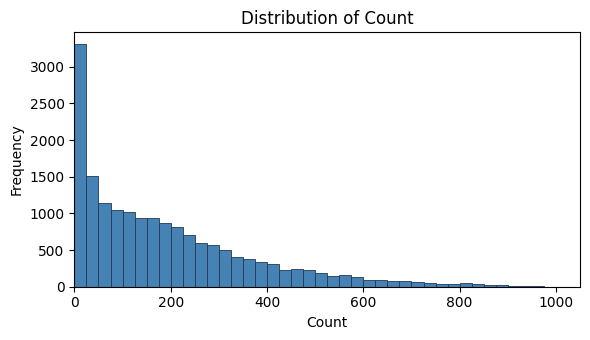

In [172]:
# 1) Count distribution
print("Count Skewness:", round(y.skew(), 3))
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(y, bins=np.arange(0, y.max() + 25, 25), color="steelblue", edgecolor="#1f3a56", linewidth=0.6)
ax.set_title("Distribution of Count")
ax.set_xlabel("Count")
ax.set_ylabel("Frequency")
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()


               temp     atemp  humidity  windspeed
temp       1.000000  0.987672 -0.069881  -0.023125
atemp      0.987672  1.000000 -0.051918  -0.062336
humidity  -0.069881 -0.051918  1.000000  -0.290105
windspeed -0.023125 -0.062336 -0.290105   1.000000


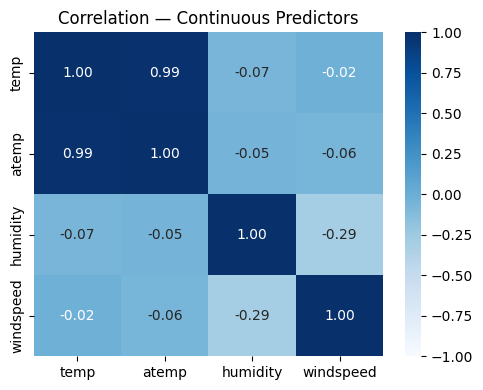

,feature,VIF
9,atemp,43.96
8,temp,43.74
0,season,3.50
2,month,3.29
10,humidity,1.53
7,weather,1.28
11,windspeed,1.20
3,hour,1.12
4,holiday,1.08
6,workingday,1.07


In [173]:
# 2) Multicollinearity — correlation among continuous predictors
continuous = ["temp", "atemp", "humidity", "windspeed"]
corr = X[continuous].corr()
print(corr)
# print("temp vs atemp correlation:", round(corr.loc["temp", "atemp"], 3))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation — Continuous Predictors")
plt.tight_layout()
plt.show()

# Variance Inflation Factor (VIF) for all predictors in X (numeric as-is for a screening check)
def compute_vif(data):
    rows = []
    for col in data.columns:
        y_i = data[col]
        X_i = data.drop(columns=col)
        r2 = LinearRegression().fit(X_i, y_i).score(X_i, y_i)
        vif = np.inf if r2 >= 1 else 1 / (1 - r2)
        rows.append({"feature": col, "VIF": vif})
    return pd.DataFrame(rows).sort_values("VIF", ascending=False)

vif_df = compute_vif(X.astype(float))
vif_df.round(2)


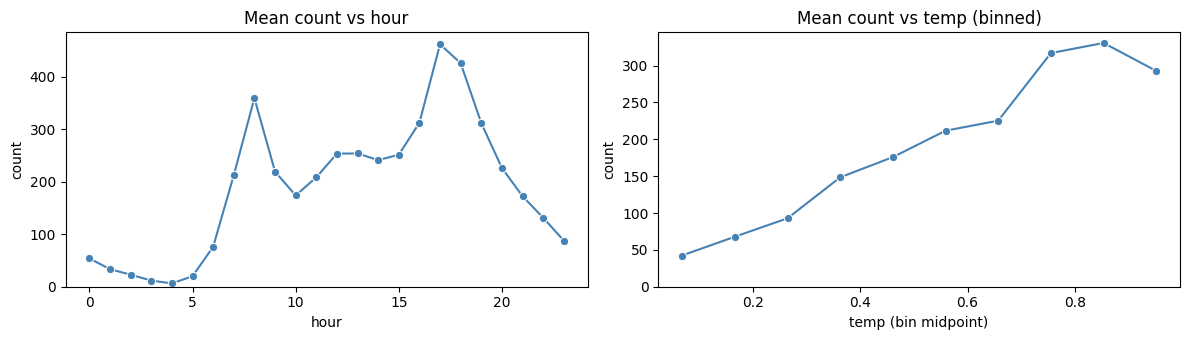

In [174]:
# 3) Non-linearity screen — mean count vs hour and temp
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

by_hour = df.groupby("hour", as_index=False)["count"].mean()
sns.lineplot(data=by_hour, x="hour", y="count", marker="o", ax=axes[0], color="steelblue")
axes[0].set_title("Mean count vs hour")
axes[0].set_ylim(bottom=0)

df_temp = df.assign(temp_bin=pd.cut(df["temp"], bins=10))
by_temp = df_temp.groupby("temp_bin", observed=True)["count"].mean().reset_index()
by_temp["temp_mid"] = by_temp["temp_bin"].apply(lambda x: x.mid)
sns.lineplot(data=by_temp, x="temp_mid", y="count", marker="o", ax=axes[1], color="steelblue")
axes[1].set_title("Mean count vs temp (binned)")
axes[1].set_xlabel("temp (bin midpoint)")
axes[1].set_ylim(bottom=0)

plt.tight_layout()
plt.show()


**Notes from the checks above**

- `count` is right-skewed → OLS is still a useful baseline, but it is not a perfect count model. Most hours are moderate or low; a smaller set of very busy hours pulls the mean up, so a typical hour is often quieter than the average.
- `temp` and `atemp` are highly collinear → keep `temp`, drop `atemp`.
- Mean demand vs `hour` (and vs `temp`) is not linear → treat `hour` as categorical; compare linear vs quadratic `temp`.
- `workingday` is determined by `weekday` + `holiday` → omit it so the design matrix stays identifiable.


### 4.3 Regression model

Fit OLS with calendar and weather codes as categoricals. Compare a linear `temp` model to one with `temp` + `temp²` (quadratic in temperature).

**Columns dropped before fitting**

| Column | Reason |
|--------|--------|
| `atemp` | Nearly the same information as `temp` (high collinearity) |
| `workingday` | Fully determined by `weekday` + `holiday`; dropping it keeps the design matrix identifiable |



In [175]:
# Drop atemp (collinearity with temp). Omit workingday: it is determined by weekday + holiday.
predictors = [c for c in predictors if c not in ("atemp", "workingday")]
X = df[predictors]
print("Predictors:", predictors)

cat_terms = (
    "C(season) + C(year) + C(month) + C(hour) + "
    "C(holiday) + C(weekday) + C(weather)"
)
continuous_linear = "temp + humidity + windspeed"

formula_linear = f"count ~ {cat_terms} + {continuous_linear}"
formula_poly = f"count ~ {cat_terms} + temp + I(temp**2) + humidity + windspeed"

ols_linear = smf.ols(formula_linear, data=df).fit()
ols_poly = smf.ols(formula_poly, data=df).fit()

compare = pd.DataFrame({
    "model": ["linear_temp", "quadratic_temp"],
    "adj_R2": [ols_linear.rsquared_adj, ols_poly.rsquared_adj],
    "AIC": [ols_linear.aic, ols_poly.aic],
    "BIC": [ols_linear.bic, ols_poly.bic],
})
compare


Predictors: ['season', 'year', 'month', 'hour', 'holiday', 'weekday', 'weather', 'temp', 'humidity', 'windspeed']


,model,adj_R2,AIC,BIC
0,linear_temp,0.685117,210052.710597,210456.387526
1,quadratic_temp,0.685220,210048.012917,210459.452863


In [176]:
# Prefer the better-fitting temp specification
ols_model = ols_poly if ols_poly.aic < ols_linear.aic else ols_linear
print("Selected:", "quadratic_temp" if ols_model is ols_poly else "linear_temp")
print(ols_model.summary())

Selected: quadratic_temp
                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.685
Method:                 Least Squares   F-statistic:                     728.5
Date:                Thu, 17 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:21:01   Log-Likelihood:            -1.0497e+05
No. Observations:               17379   AIC:                         2.100e+05
Df Residuals:                   17326   BIC:                         2.105e+05
Df Model:                          52                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        

### 4.4 Diagnostics and interpretation

Review fitted values and residuals for the selected OLS model, then read the main coefficients in context of the EDA.



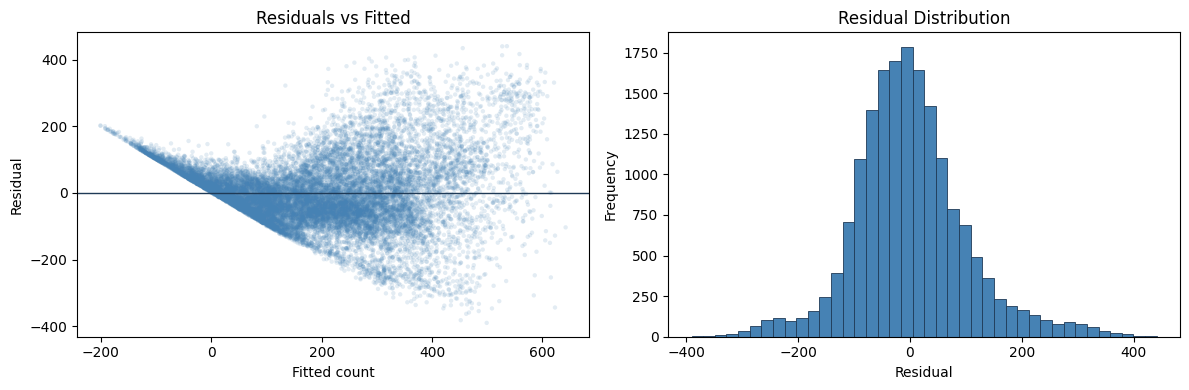

Residual mean: -0.0
Residual std: 101.62


In [177]:
fitted = ols_model.fittedvalues
resid = ols_model.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuals vs fitted
axes[0].scatter(fitted, resid, alpha=0.15, s=10, color="steelblue", edgecolors="none")
axes[0].axhline(0, color="#1f3a56", linewidth=1)
axes[0].set_title("Residuals vs Fitted")
axes[0].set_xlabel("Fitted count")
axes[0].set_ylabel("Residual")

# Residual histogram
axes[1].hist(resid, bins=40, color="steelblue", edgecolor="#1f3a56", linewidth=0.6)
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print("Residual mean:", round(resid.mean(), 4))
print("Residual std:", round(resid.std(), 2))


### 4.5 Regression summary

- Selected model: **quadratic temperature** OLS (lower AIC than linear `temp` alone).
- Fit: R² ≈ **0.69** — about two-thirds of the variation in hourly `count` is explained.
- **Temperature:** positive `temp` and a significant `temp²` term point to a non-linear warmth effect.
- **Humidity / windspeed:** both associated with lower demand, holding other factors fixed.
- **Weather:** mist and light precipitation go with lower demand than clear conditions. Heavy weather is rare, so that estimate is less stable.
- **Hour / season / month / weekday:** categorical effects pick up the non-linear time patterns from EDA (commute peaks, seasonal level shifts).
- **Diagnostics:** Residuals vs fitted stay roughly centered on 0 across predicted demand, but the spread is still large (and can widen at higher fitted values). The residual histogram is also centered near 0, with skew typical of count data. OLS is a solid explanatory baseline, not a perfect distributional model.
- **Variable selection:** dropped `atemp` (collinear with `temp`) and `workingday` (redundant with `weekday` + `holiday`).


## 5. Feature Engineering

Set up leakage-safe inputs for hourly forecasting: choose features, add `temp_sq`, and prepare the categorical and continuous fields.

### 5.1 Forecasting setup

- **Target:** hourly `count`
- **Split:** train = days 1–20 of each month; test = day 21–end
- **Leakage rule:** only use information available for that hour — no `casual` / `registered`, and no future values
- **Base table:** cleaned hourly data (`data/processed/bike_hourly_clean.csv`)


In [178]:
df_fe = pd.read_csv(
    Path("data/processed/bike_hourly_clean.csv"),
    parse_dates=["datetime"],
)

target = "count"
print("Rows:", len(df_fe))
print("Target:", target)
print("dayofmonth range:", df_fe["dayofmonth"].min(), "→", df_fe["dayofmonth"].max())
df_fe.head()


Rows: 17379
Target: count
dayofmonth range: 1 → 31


,season,year,month,hour,holiday,weekday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,datetime,dayofmonth
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,2011-01-01 00:00:00,1
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,2011-01-01 01:00:00,1
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,2011-01-01 02:00:00,1
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,2011-01-01 03:00:00,1
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,2011-01-01 04:00:00,1


### 5.2 Feature list

Features used to predict hourly `count`. Everything is from the same hour’s calendar and weather — no demand outcomes.

| Type | Features | Why included / safe |
|------|----------|---------------------|
| Calendar | `hour`, `weekday`, `month`, `year`, `season`, `holiday` | Calendar attributes of that same hour |
| Weather | `weather`, `temp`, `humidity`, `windspeed` | Recorded on the same row (no future rows) |
| Engineered | `temp_sq` (`temp²`) | Built from same-hour `temp`; quadratic temp had a better regression fit (higher adj. R² / lower AIC) |

**Excluded (leakage / redundancy)**

| Excluded | Reason |
|----------|--------|
| `casual`, `registered` | They make up `count` (target leakage) |
| `atemp` | Collinear with `temp` |
| `workingday` | Determined by `weekday` + `holiday` |
| `datetime` | Kept for ordering/reference only — not a model feature |
| `dayofmonth` | Used for the train/test split only — not a predictor |



In [179]:
# Build forecasting frame: target + leakage-safe features + split helper columns
df_fe = df_fe.copy()
df_fe["temp_sq"] = df_fe["temp"] ** 2

feature_cols = [
    "hour",
    "weekday",
    "month",
    "year",
    "season",
    "holiday",
    "weather",
    "temp",
    "temp_sq",
    "humidity",
    "windspeed",
]
split_cols = ["datetime", "dayofmonth"]  # for partitioning later — not model inputs

df_model = df_fe[split_cols + feature_cols + [target]].copy()

print("Model features:", feature_cols)
print("Split helpers:", split_cols)
print("Excluded from X:", ["casual", "registered", "atemp", "workingday", "datetime", "dayofmonth"])
print("df_model shape:", df_model.shape)
df_model.head()


Model features: ['hour', 'weekday', 'month', 'year', 'season', 'holiday', 'weather', 'temp', 'temp_sq', 'humidity', 'windspeed']
Split helpers: ['datetime', 'dayofmonth']
Excluded from X: ['casual', 'registered', 'atemp', 'workingday', 'datetime', 'dayofmonth']
df_model shape: (17379, 14)


,datetime,dayofmonth,hour,weekday,month,year,season,holiday,weather,temp,temp_sq,humidity,windspeed,count
0,2011-01-01 00:00:00,1,0,6,1,0,1,0,1,0.24,0.0576,0.81,0.0,16
1,2011-01-01 01:00:00,1,1,6,1,0,1,0,1,0.22,0.0484,0.80,0.0,40
2,2011-01-01 02:00:00,1,2,6,1,0,1,0,1,0.22,0.0484,0.80,0.0,32
3,2011-01-01 03:00:00,1,3,6,1,0,1,0,1,0.24,0.0576,0.75,0.0,13
4,2011-01-01 04:00:00,1,4,6,1,0,1,0,1,0.24,0.0576,0.75,0.0,1


### 5.3 Encoding plan

Prepare features by type before modeling. **Fit** encoders/scalers on train rows only (days 1–20). **Transform** train and test with those fits — do not refit on test or on the full table.

| Role | Features | Treatment |
|------|----------|-----------|
| Categorical | `hour`, `weekday`, `month`, `year`, `season`, `holiday`, `weather` | One-hot encode (drop first level to avoid the dummy trap) |
| Continuous | `temp`, `temp_sq`, `humidity`, `windspeed` | Keep numeric; standardize after the split |




In [180]:
categorical_cols = [
    "hour",
    "weekday",
    "month",
    "year",
    "season",
    "holiday",
    "weather",
]
continuous_cols = [
    "temp",
    "temp_sq",
    "humidity",
    "windspeed",
]

assert set(categorical_cols + continuous_cols) == set(feature_cols)
print("Categorical:", categorical_cols)
print("Continuous:", continuous_cols)

Categorical: ['hour', 'weekday', 'month', 'year', 'season', 'holiday', 'weather']
Continuous: ['temp', 'temp_sq', 'humidity', 'windspeed']


## 6. Demand Forecasting

Predict hourly `count` with the features from Step 5. Train on days 1–20 of each month and evaluate on day 21–end. Encode and scale using train only.



### 6.1 Train/test split

Split: **train** = `dayofmonth` 1–20; **test** = 21–end. Features and target come from `df_model` (no `casual` / `registered`).



In [181]:
train = df_model[df_model["dayofmonth"] <= 20].copy()
test = df_model[df_model["dayofmonth"] > 20].copy()

X_train = train[feature_cols]
y_train = train[target]
X_test = test[feature_cols]
y_test = test[target]

print("Train:", X_train.shape, "| days", train["dayofmonth"].min(), "–", train["dayofmonth"].max())
print("Test: ", X_test.shape, "| days", test["dayofmonth"].min(), "–", test["dayofmonth"].max())
print("Train date range:", train["datetime"].min(), "→", train["datetime"].max())
print("Test date range: ", test["datetime"].min(), "→", test["datetime"].max())


Train: (11460, 11) | days 1 – 20
Test:  (5919, 11) | days 21 – 31
Train date range: 2011-01-01 00:00:00 → 2012-12-20 23:00:00
Test date range:  2011-01-21 00:00:00 → 2012-12-31 23:00:00


### 6.2 Encode and scale (train only)

One-hot encode categoricals and standardize continuous features with a sklearn `ColumnTransformer`. Fit on **train**, then apply the same transform to train and test.



In [182]:
preprocess = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
            categorical_cols,
        ),
        ("num", StandardScaler(), continuous_cols),
    ]
)

X_train_enc = preprocess.fit_transform(X_train)
X_test_enc = preprocess.transform(X_test)

encoded_cols = preprocess.get_feature_names_out()
X_train_enc_df = pd.DataFrame(X_train_enc, columns=encoded_cols)
X_test_enc_df = pd.DataFrame(X_test_enc, columns=encoded_cols)

print("Encoded train shape:", X_train_enc_df.shape)
print("Encoded test shape: ", X_test_enc_df.shape)

print("\nEncoded train (head):")
display(X_train_enc_df.head())
print("Encoded test (head):")
display(X_test_enc_df.head())


Encoded train shape: (11460, 52)
Encoded test shape:  (5919, 52)

Encoded train (head):


,cat__hour_1,cat__hour_2,cat__hour_3,cat__hour_4,cat__hour_5,cat__hour_6,cat__hour_7,cat__hour_8,cat__hour_9,cat__hour_10,...,cat__season_3,cat__season_4,cat__holiday_1,cat__weather_2,cat__weather_3,cat__weather_4,num__temp,num__temp_sq,num__humidity,num__windspeed
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-1.342597,-1.164995,0.991039,-1.556109
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-1.448375,-1.213265,0.938878,-1.556109
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-1.448375,-1.213265,0.938878,-1.556109
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-1.342597,-1.164995,0.678071,-1.556109
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-1.342597,-1.164995,0.678071,-1.556109


Encoded test (head):


,cat__hour_1,cat__hour_2,cat__hour_3,cat__hour_4,cat__hour_5,cat__hour_6,cat__hour_7,cat__hour_8,cat__hour_9,cat__hour_10,...,cat__season_3,cat__season_4,cat__holiday_1,cat__weather_2,cat__weather_3,cat__weather_4,num__temp,num__temp_sq,num__humidity,num__windspeed
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,-1.342597,-1.164995,0.417264,0.523079
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,-1.342597,-1.164995,0.417264,0.523079
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,-1.342597,-1.164995,0.678071,-0.210414
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,-1.448375,-1.213265,0.938878,0.890236
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,-1.448375,-1.213265,1.304007,-0.821796


### 6.3 Models

- **Hour-mean baseline** — for each hour of day, predict the train-set mean `count` (no other features).
- **Linear regression** — same encoded calendar/weather features (in line with the Step 4 OLS setup).
- **Random forest** — non-linear ensemble for the stronger hourly forecast.



In [183]:
# Naive baseline: mean count by hour, learned from train only
hour_mean = train.groupby("hour")[target].mean()
y_pred_hour = test["hour"].map(hour_mean).fillna(y_train.mean()).to_numpy()

results = []
predictions = {"HourMeanBaseline": y_pred_hour}
results.append(
    {
        "model": "HourMeanBaseline",
        "RMSE": float(np.sqrt(mean_squared_error(y_test, y_pred_hour))),
        "MAE": float(mean_absolute_error(y_test, y_pred_hour)),
        "R2": float(r2_score(y_test, y_pred_hour)),
    }
)

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ),
}

for name, model in models.items():
    model.fit(X_train_enc, y_train)
    y_pred = model.predict(X_test_enc)
    predictions[name] = y_pred
    results.append(
        {
            "model": name,
            "RMSE": float(np.sqrt(mean_squared_error(y_test, y_pred))),
            "MAE": float(mean_absolute_error(y_test, y_pred)),
            "R2": float(r2_score(y_test, y_pred)),
        }
    )

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
display(results_df.round(3))
best_name = results_df.iloc[0]["model"]
print("Best by test RMSE:", best_name)


,model,RMSE,MAE,R2
0,RandomForest,83.330,55.849,0.788
1,LinearRegression,105.927,78.630,0.658
2,HourMeanBaseline,132.364,91.062,0.466


Best by test RMSE: RandomForest


### 6.4 Diagnostics

On the **test** set, plot predicted vs actual and residuals for the best model by RMSE.



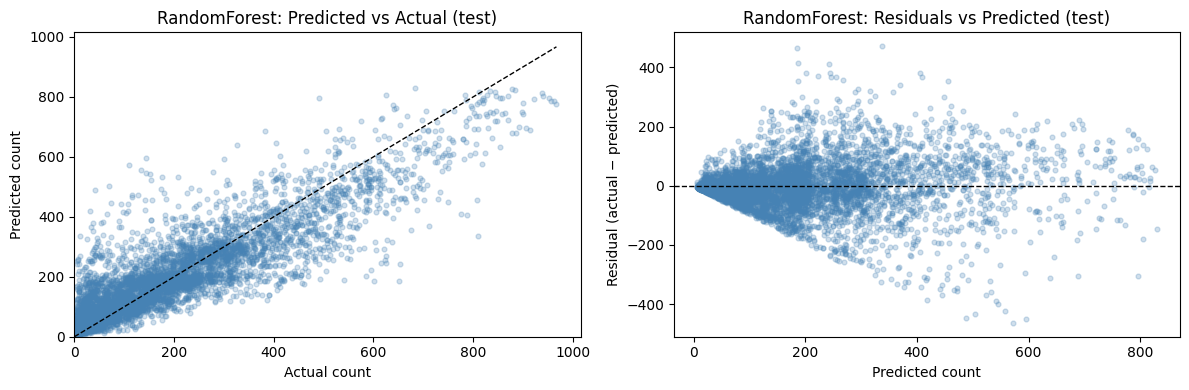

In [184]:
y_pred_best = predictions[best_name]
resid = y_test.to_numpy() - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test, y_pred_best, alpha=0.25, s=12, color="steelblue")
lims = [0, max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, color="black", linewidth=1, linestyle="--")
axes[0].set_title(f"{best_name}: Predicted vs Actual (test)")
axes[0].set_xlabel("Actual count")
axes[0].set_ylabel("Predicted count")
axes[0].set_xlim(left=0)
axes[0].set_ylim(bottom=0)

axes[1].scatter(y_pred_best, resid, alpha=0.25, s=12, color="steelblue")
axes[1].axhline(0, color="black", linewidth=1, linestyle="--")
axes[1].set_title(f"{best_name}: Residuals vs Predicted (test)")
axes[1].set_xlabel("Predicted count")
axes[1].set_ylabel("Residual (actual − predicted)")

plt.tight_layout()
plt.show()


### 6.5 Feature importance

Top predictors from the fitted random forest, using the encoded feature names.



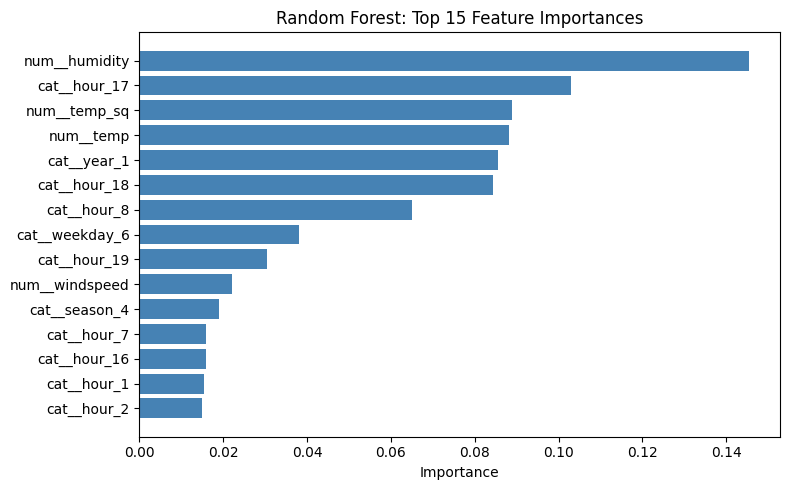

,feature,importance
0,num__humidity,0.145574
1,cat__hour_17,0.103078
2,num__temp_sq,0.088901
3,num__temp,0.088206
4,cat__year_1,0.085573
5,cat__hour_18,0.084473
6,cat__hour_8,0.064941
7,cat__weekday_6,0.038056
8,cat__hour_19,0.030331
9,num__windspeed,0.022049


In [185]:
rf_model = models["RandomForest"]
importance = (
    pd.Series(rf_model.feature_importances_, index=encoded_cols)
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance.index[::-1], importance.values[::-1], color="steelblue")
ax.set_title("Random Forest: Top 15 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

display(importance.rename("importance").reset_index().rename(columns={"index": "feature"}))


### 6.6 Forecasting summary

- Split: train on days 1–20; test on day 21–end. Preprocessing is fit on train only.
- Compared an **hour-mean baseline**, linear regression, and random forest on test RMSE, MAE, and R².
- **Random forest** does best overall. Both ML models beat the hour-mean baseline.
- Feature importance points to calendar and weather drivers — especially hour-related encodings and temperature.
- `casual` and `registered` were not used as predictors.



In [186]:
print("Test-set performance")
display(results_df.round(3))


Test-set performance


,model,RMSE,MAE,R2
0,RandomForest,83.330,55.849,0.788
1,LinearRegression,105.927,78.630,0.658
2,HourMeanBaseline,132.364,91.062,0.466


## 7. Conclusions

- Hourly demand is driven mainly by **time of day** (commute peaks) and **weather**. Casual and registered users follow different patterns.
- OLS supported a non-linear temperature effect: **quadratic temp** fit better than linear temp alone.
- Forecasting used same-hour calendar and weather features only (no `casual`/`registered`), with a **days 1–20 / 21–end** split and train-only encoding/scaling.
- Relative to an **hour-mean baseline**, linear regression and especially **random forest** improve test RMSE, MAE, and R². RF feature importances line up with the EDA story: hour and temperature matter most.

